In [101]:

import torch.nn as nn
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

In [102]:
G=1
T=1000
estadistica='promedio'
hidden=(10,10) 
path_uniform = f"symmetric/{G}redes{estadistica}/nets_best_by_gid_uniform_{T}.pt"
path_discriminatory = f"symmetric/{G}redes{estadistica}/nets_best_by_gid_pay_as_bid_{T}.pt"

In [103]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNet(nn.Module):
    def __init__(self, input_dim: int, hidden=(10,10), output_dim: int = 1,
                 floor_mode: str = "max", min_bid: float = 1e-6):
        super().__init__()
        layers = []
        d = int(input_dim)
        for h in hidden:
            layers += [nn.Linear(d, int(h)), nn.ReLU()]
            d = int(h)
        layers += [nn.Linear(d, int(output_dim))]
        self.net = nn.Sequential(*layers)

        # parámetros “no entrenables” (puedes cambiar por llamada)
        self.floor_mode = floor_mode
        self.min_bid = float(min_bid)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Devuelve BID factible:
          r(x) = f_theta(x)              (salida latente)
          bid = Gamma_phi(r(x))         (transformación factible)
          bid >= phi  (si x es phi escalar) o bid >= max_h phi_h / mean_h phi_h
        """
        raw = self.net(x).reshape(-1)   # salida latente r(x)

        if x.ndim == 2 and x.shape[1] > 1:
            if self.floor_mode == "max":
                floor = x.max(dim=1).values
            elif self.floor_mode == "mean":
                floor = x.mean(dim=1)
            else:
                raise ValueError("floor_mode must be 'max' or 'mean'")
        else:
            floor = x.reshape(-1)

        floor = torch.clamp_min(floor, 0.0)
        bid = floor + F.softplus(raw)+0.08
        return bid


In [104]:

saved_nets_uniform = torch.load(path_uniform, map_location="cpu")

gid = 1
net_uniform = PolicyNet(
    input_dim=24,
    hidden=hidden,
    output_dim=1,
    floor_mode="mean",   # <- igual que en entrenamiento
    min_bid=1e-6         # <- igual que en entrenamiento
)
net_uniform.load_state_dict(saved_nets_uniform[gid], strict=True)
net_uniform.eval() # importante para modo evaluación




saved_nets_discriminatory = torch.load(path_discriminatory, map_location="cpu")

gid = 1
net_discriminatory = PolicyNet(
    input_dim=24,
    hidden=hidden,
    output_dim=1,
    floor_mode="mean",   # <- igual que en entrenamiento
    min_bid=1e-6         # <- igual que en entrenamiento
)
net_discriminatory.load_state_dict(saved_nets_discriminatory[gid], strict=True)
net_discriminatory.eval() # importante para modo evaluación

PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [105]:
CSV_PATH = "symmetric/grupos.csv"   # <-- adjust
input = pd.read_csv(CSV_PATH)


In [106]:
input

,id_planta,Fecha,phi,Grupo,precio_d
0,1,2025-04-01,0.083924,1,0.10137
1,2,2025-04-01,0.262222,5,0.28295
2,3,2025-04-01,0.275288,5,0.32637
3,4,2025-04-01,0.260380,5,0.31037
4,5,2025-04-01,0.968472,4,1.02813
...,...,...,...,...,...
4207,32,2025-09-09,0.779362,4,0.90894
4208,33,2025-09-09,1.058581,4,1.11735
4209,34,2025-09-09,0.945489,4,1.01274
4210,35,2025-09-09,0.969786,4,1.18348


In [107]:
import torch

# Suponiendo que tu DataFrame se llama input
def phi_a_tensor_24(phi_val):
    """Recibe un valor escalar y devuelve un tensor (1,24) duplicado"""
    arr = [phi_val] * 24  # lista de 24 valores iguales
    return torch.tensor([arr], dtype=torch.float)  # shape (1,24)
# Lista para guardar resultados

predicciones_uniform = []
predicciones_discriminatory = []
for i, row in input.iterrows():
    x = phi_a_tensor_24(row['phi'])
    y_pred_uniform = net_uniform(x)
    y_pred_discrimininatoty = net_discriminatory(x)
    predicciones_uniform.append(y_pred_uniform.item())  # convertir de tensor a float
    predicciones_discriminatory.append(y_pred_discrimininatoty.item()) 

In [108]:
predicciones_uniform

[0.185538187623024,
 0.3628252148628235,
 0.3758193850517273,
 0.36099356412887573,
 1.0654997825622559,
 0.3905866742134094,
 0.19738662242889404,
 0.1872289776802063,
 0.3181798458099365,
 0.3319833278656006,
 0.3571215271949768,
 0.36481016874313354,
 0.32400187849998474,
 0.42675668001174927,
 0.46568208932876587,
 0.958926260471344,
 0.9652923941612244,
 0.3273732662200928,
 0.603361189365387,
 0.5918707251548767,
 1.452006220817566,
 1.28395676612854,
 0.3273732662200928,
 0.1385410726070404,
 2.383226156234741,
 0.4454716444015503,
 1.7944443225860596,
 1.698887825012207,
 0.928616464138031,
 0.813012421131134,
 0.8505949974060059,
 1.0058025121688843,
 1.5080931186676025,
 1.5143656730651855,
 1.2140724658966064,
 1.4521664381027222,
 0.1734423041343689,
 1.043761968612671,
 0.32909998297691345,
 0.3244015574455261,
 1.0700191259384155,
 0.3855973482131958,
 0.19281919300556183,
 0.18587526679039001,
 0.29276975989341736,
 0.2955911159515381,
 0.3374630808830261,
 0.37491554021

In [109]:
predicciones_discriminatory

[0.33340227603912354,
 0.5116806030273438,
 0.5247457027435303,
 0.509838879108429,
 1.217679500579834,
 0.5395933985710144,
 0.34531861543655396,
 0.335102915763855,
 0.4667893052101135,
 0.48066914081573486,
 0.5059456825256348,
 0.5136764049530029,
 0.4726436138153076,
 0.5759555697441101,
 0.6150840520858765,
 1.1106525659561157,
 1.1170461177825928,
 0.47603362798690796,
 0.7534637451171875,
 0.7419158220291138,
 1.6057143211364746,
 1.437022089958191,
 0.47603362798690796,
 0.28613102436065674,
 2.5399863719940186,
 0.5947684049606323,
 1.949363350868225,
 1.8534826040267944,
 1.0802111625671387,
 0.9640941023826599,
 1.001845359802246,
 1.157729983329773,
 1.6620086431503296,
 1.668304204940796,
 1.3668606281280518,
 1.6058752536773682,
 0.3212359547615051,
 1.1958503723144531,
 0.4777699112892151,
 0.4730455279350281,
 1.2222176790237427,
 0.534576952457428,
 0.340725302696228,
 0.33374130725860596,
 0.4412379264831543,
 0.4440750479698181,
 0.4861791133880615,
 0.5238369703292

In [110]:
input['est_uni']=predicciones_uniform
input['est_dis']=predicciones_discriminatory
input['diff']=input['est_dis']-input['est_uni']

<Figure size 3600x1500 with 0 Axes>

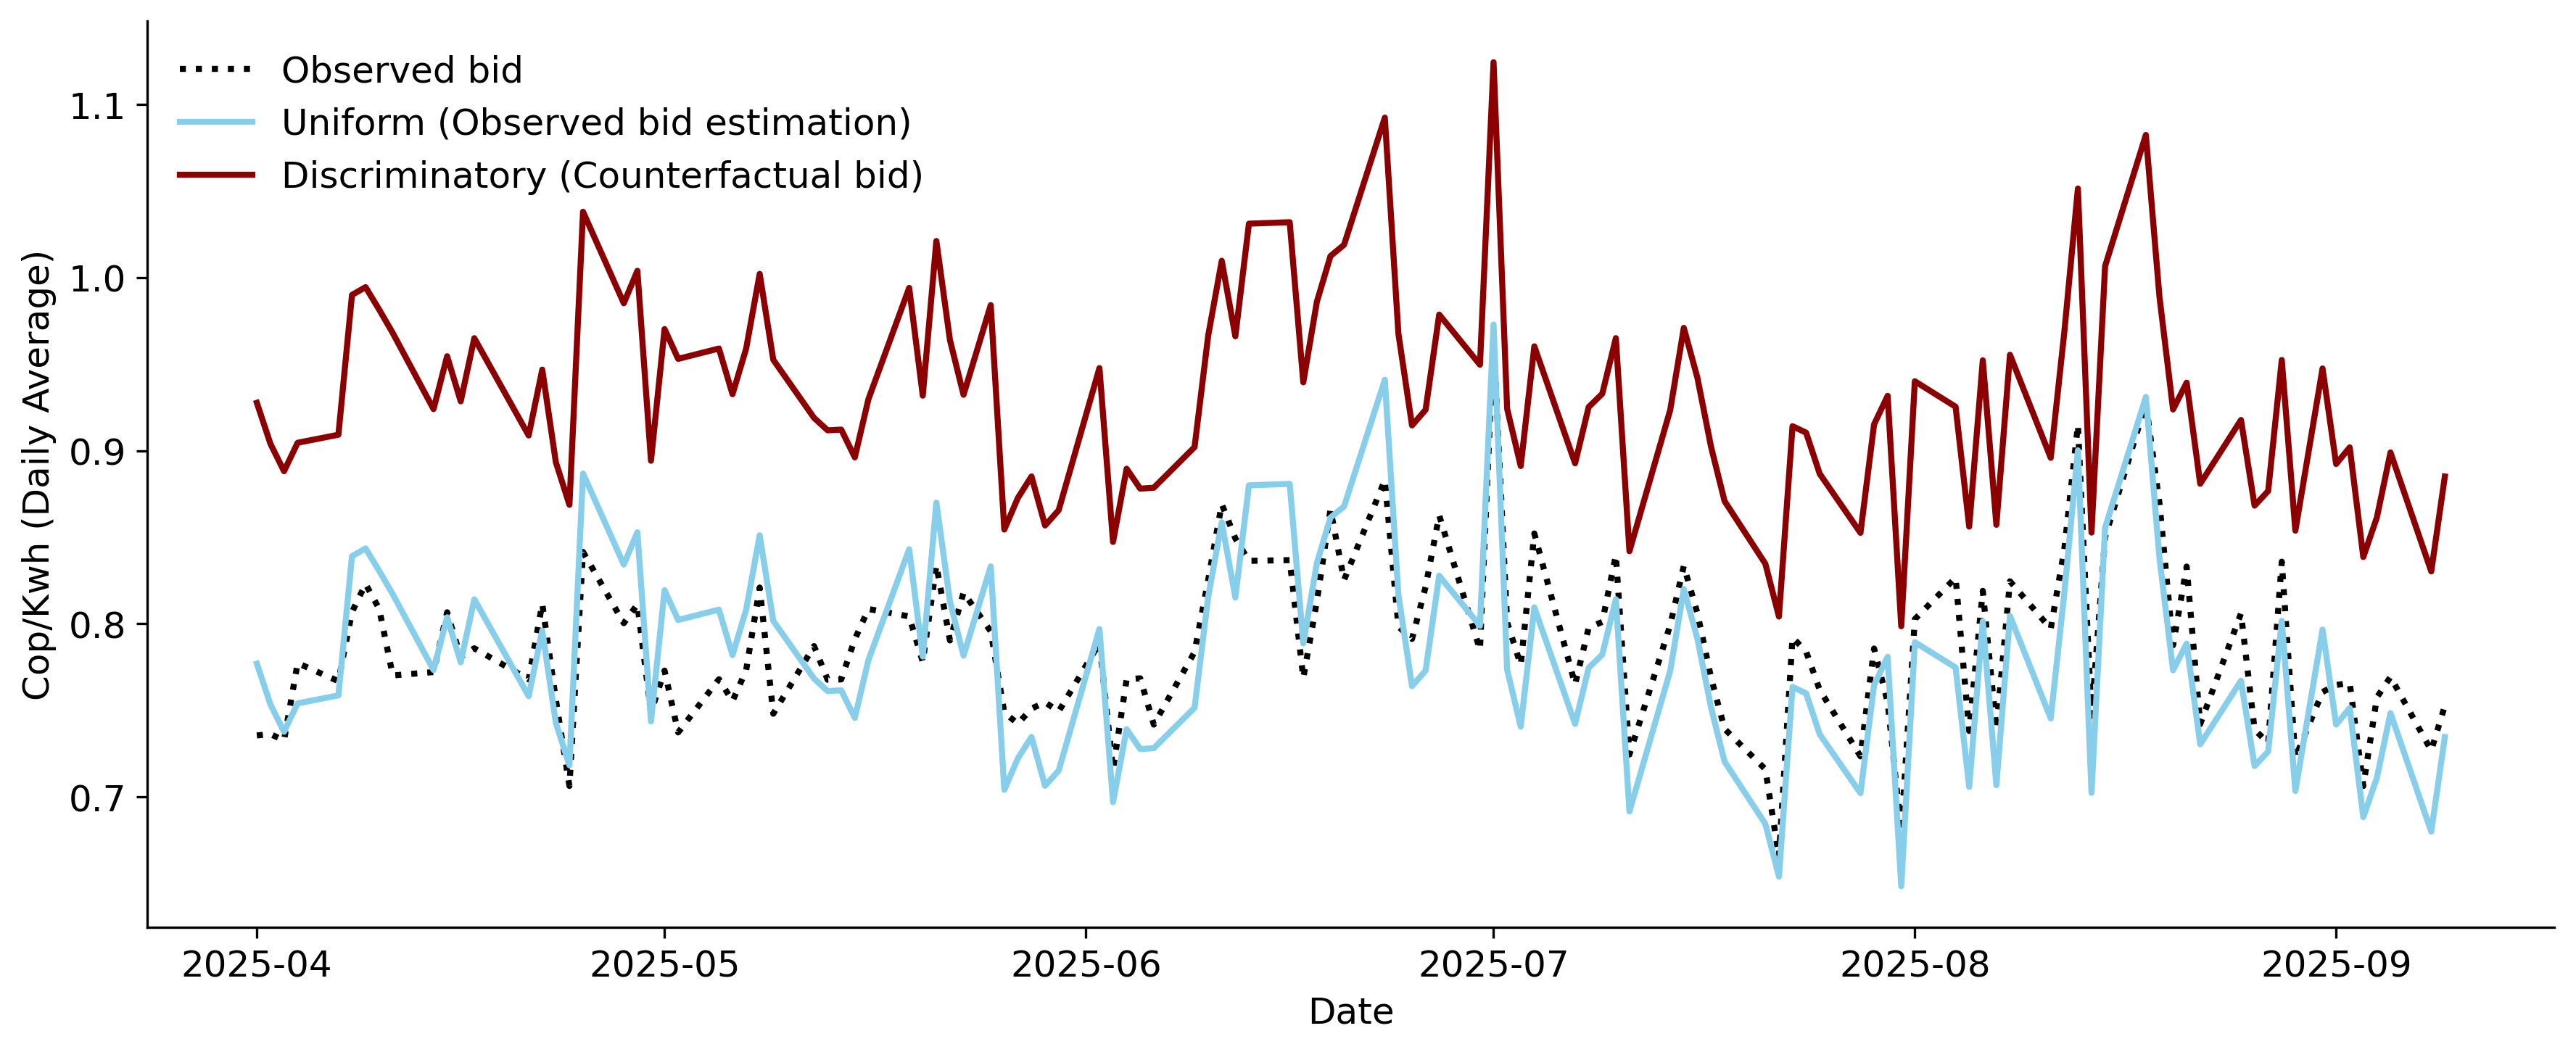

In [111]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# --- Agrupar por fecha y calcular promedio de todas las plantas ---
df_daily = input.groupby(input["Fecha"].dt.date)[
    ["precio_d", "est_uni", "est_dis"]
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# Agrupar por fecha y calcular promedio
df_daily = input.groupby(input["Fecha"].dt.date)[
    ["precio_d", "est_uni", "est_dis"]
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

# --- Líneas con colores y estilos ---
plt.plot(df_daily["Fecha"], df_daily["precio_d"], label="Observed bid",
         color="black", linestyle=":", linewidth=2)        # línea punteada
plt.plot(df_daily["Fecha"], df_daily["est_uni"], label="Uniform (Observed bid estimation)",
         color="skyblue", linewidth=2)
plt.plot(df_daily["Fecha"], df_daily["est_dis"], label="Discriminatory (Counterfactual bid)",
         color="darkred", linewidth=2)


plt.xlabel("Date")
plt.ylabel("Cop/Kwh (Daily Average)")
#plt.title("Promedio diario por fecha de todas las plantas")
plt.legend(frameon=False)
plt.grid(False)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_7828\2379210048.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


<Figure size 3600x1500 with 0 Axes>

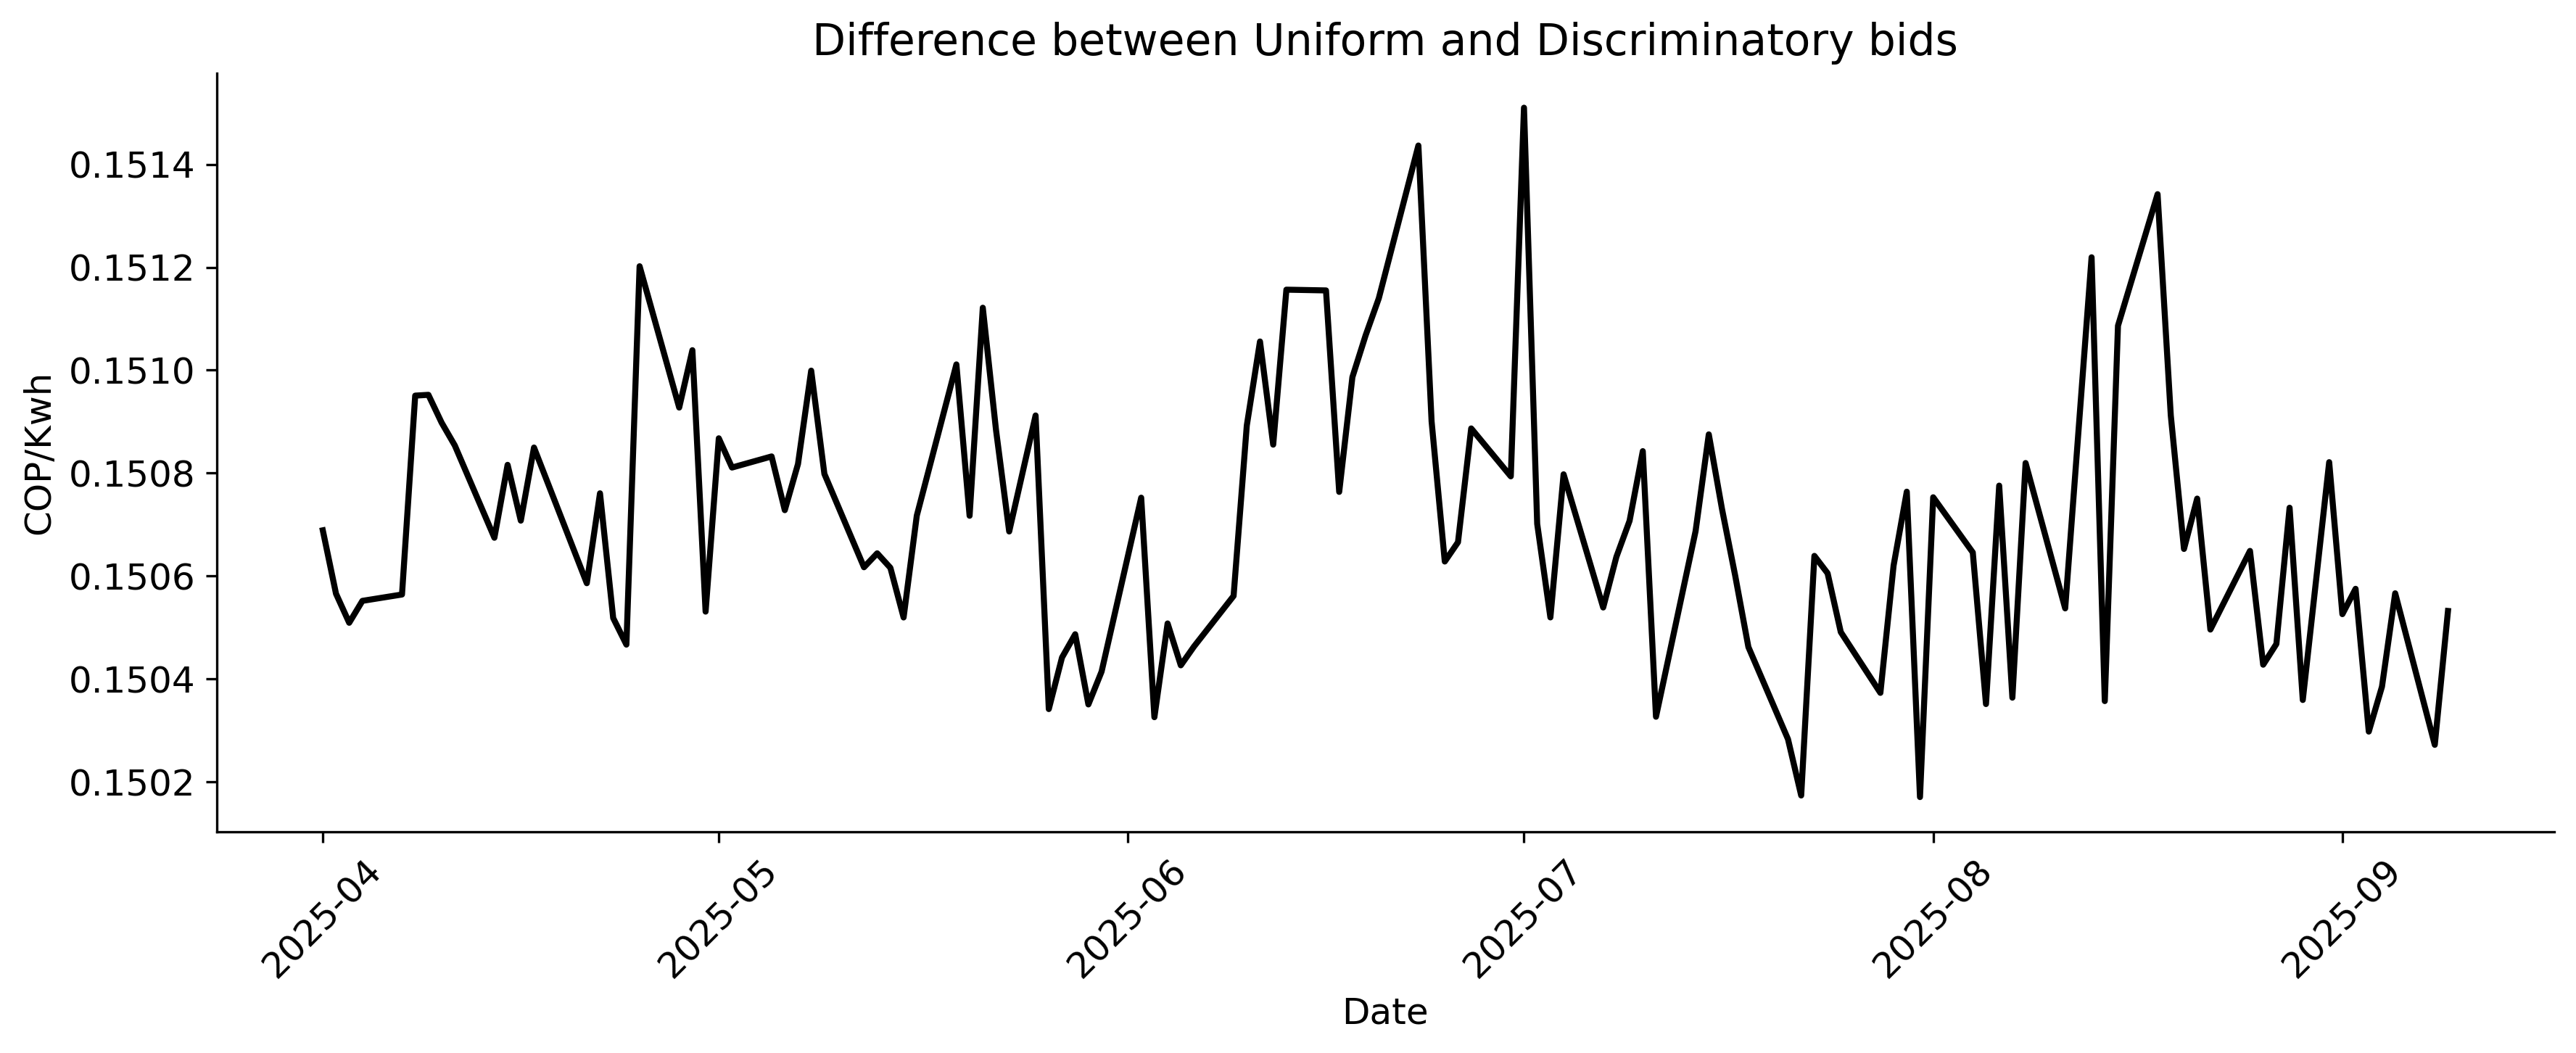

In [112]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# --- Agrupar por fecha y calcular promedio de todas las plantas ---
df_daily = input.groupby(input["Fecha"].dt.date)[
    ['diff']
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# Asegurarse que "Fecha" es datetime
input["Fecha"] = pd.to_datetime(input["Fecha"])

# Agrupar por fecha y calcular promedio
df_daily = input.groupby(input["Fecha"].dt.date)[
    ['diff']
].mean().reset_index()

plt.figure(figsize=(12,5), dpi=300)

# --- Líneas con colores y estilos ---
plt.plot(df_daily["Fecha"], df_daily["diff"],
         color="black", linewidth=2)        # línea punteada

plt.xlabel("Date")
plt.ylabel("COP/Kwh")
plt.title("Difference between Uniform and Discriminatory bids")
plt.legend(frameon=False)
plt.grid(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [113]:
df_daily

,Fecha,diff
0,2025-04-01,0.150689
1,2025-04-02,0.150566
2,2025-04-03,0.150509
3,2025-04-04,0.150552
4,2025-04-07,0.150564
...,...,...
112,2025-09-03,0.150298
113,2025-09-04,0.150385
114,2025-09-05,0.150567
115,2025-09-08,0.150272


## Equilibrios

In [114]:
import torch
import torch.nn.functional as F

x = phi_a_tensor_24(1.255597)
with torch.no_grad():
    raw = net_uniform.net(x).reshape(-1)
    if x.ndim == 2 and x.shape[1] > 1:
        phi_floor = x.max(dim=1).values if net_uniform.floor_mode == "max" else x.mean(dim=1)
    else:
        phi_floor = x.reshape(-1)
    phi_floor = torch.clamp_min(phi_floor, 0.0)
    bid = phi_floor + F.softplus(raw) + net_uniform.min_bid


print("raw:", raw.item())
print("phi floor:", phi_floor.item())
print("bid:", bid.item())
print("bid-phi_floor:", (bid - phi_floor).item())

raw: -4.142609596252441
phi floor: 1.2555968761444092
bid: 1.2713544368743896
bid-phi_floor: 0.01575756072998047


In [115]:
import torch
import torch.nn.functional as F

x = phi_a_tensor_24(1.255597)
with torch.no_grad():
    raw = net_discriminatory.net(x).reshape(-1)
    inc = F.softplus(raw)
    bid = net_discriminatory(x).reshape(-1)

print("raw:", raw.item())
print("softplus(raw):", inc.item())
print("bid:", bid.item(), "phi:", x.mean().item(), "bid-phi:", (bid - x.mean()).item())

raw: -1.6916295289993286
softplus(raw): 0.16908356547355652
bid: 1.5046805143356323 phi: 1.2555968761444092 bid-phi: 0.24908363819122314


## notas:
en maximo da bien, uniform es mas pequeño que discirminatory bien

## Beneficios

In [116]:
CSV_PATH = "symmetric/df_con_grupos.csv"   # <-- adjust
df = pd.read_csv(CSV_PATH)


In [117]:
df['est_uni']=predicciones_uniform
df['est_dis']=predicciones_discriminatory

In [118]:
df

,CodigoPlanta,available_q,phi,precio_d,Fecha,cluster,id_planta,daily_reman_demand,Grupo,est_uni,est_dis
0,TYP3,"[49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49.0, 49....",0.083924,0.10137,2025-04-01,10.0,1,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.185538,0.333402
1,TYP2,"[26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26....",0.262222,0.28295,2025-04-01,,2,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.362825,0.511681
2,TSJ2,"[170.0, 170.0, 170.0, 170.0, 170.0, 170.0, 170...",0.275288,0.32637,2025-04-01,10.0,3,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.375819,0.524746
3,TSJ1,"[165.0, 165.0, 165.0, 165.0, 165.0, 165.0, 165...",0.260380,0.31037,2025-04-01,10.0,4,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,0.360994,0.509839
4,MRL1,"[164.0, 164.0, 164.0, 164.0, 164.0, 164.0, 164...",0.968472,1.02813,2025-04-01,10.0,5,"[1029.7, 935.38, 843.32, 771.69, 695.0, 695.0,...",1,1.065500,1.217680
...,...,...,...,...,...,...,...,...,...,...,...
4207,TRN1,"[80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80....",0.779362,0.90894,2025-09-09,12.0,32,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",1,0.877282,1.028651
4208,TBQ4,"[60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60....",1.058581,1.11735,2025-09-09,12.0,33,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",1,1.155199,1.307749
4209,TBQ3,"[60.0, 60.0, 60.0, 60.0, 60.0, 60.0, 60.080980...",0.945489,1.01274,2025-09-09,12.0,34,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",1,1.042623,1.194707
4210,TVL1,"[241.0, 241.0, 241.0, 241.0, 241.0, 241.0, 241...",0.969786,1.18348,2025-09-09,12.0,35,"[1092.15, 1009.76, 945.22, 868.33, 808.01, 733...",1,1.066807,1.218993


In [119]:
sigma=1e-3
t=0
max(sigma, (sigma * 1e1)* (0.995 ** int(t)))


0.01

In [120]:
df.to_csv(f'symmetric/{G}redes{estadistica}/resultados_Estimaciones_{T}.csv', index=False)